# Homework 02: LP reformulation, solution cases, and indexed models

**ISyE 524 — Fall 2026**  
**Due: Monday, September 21, 2026, at 11:59 p.m. (Madison time).**  
**Coverage:** LP solution cases, standard-form reformulation, and general indexed LP models (Lectures 3–5).

**Name:** Enter your name here.

Complete all three problems. Write each mathematical formulation before implementing it, define variables and units, state assumptions and variable domains, and explain your results. Problem 2 is entirely written; parts 1(c), 3(a), and 3(c) also require no code. Parts 3(b) and 3(d) implement and solve the two production models.

Use the course Julia environment and Julia 1.12 kernel. Run the notebook from top to bottom and save it with results visible. Submit one PDF to Gradescope, with pages matched to questions.

AI tools may help debug code you wrote, explain Julia/JuMP syntax and error messages, or critique your work. They should not replace constructing your formulation, implementation, or written solution. You are responsible for understanding and checking everything you submit. Complete the collaboration and LLM-use statement at the end.


## Getting started and written answers

Follow [Assignments and PDF Submission](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/canvas-assignment-workflow.md). In VS Code, use **Tasks: Run Task** to run **ISyE 524: Update course repository**, then **ISyE 524: Start an assignment from its template**, entering `hw02`. Open `student-work/hw02/hw02.ipynb`. The copy includes its `data/` folder. An existing working copy will not be overwritten.

For **every written part**, type LaTeX mathematics in Markdown or insert a clear photograph/scan of handwritten work. Include the answer and reasoning together and label the subparts; no duplicate transcription is required. Julia/JuMP implementations belong in code cells.

Use `$x_1 \geq 0$` for inline mathematics and `$$x_1+x_2\leq5$$` for display mathematics. Run the Markdown cell to render it.

For handwritten work, edit a Markdown cell in VS Code, drag in a cropped PNG/JPEG, and choose **Insert Image as Attachment**. Alternatively, put the image beside your working notebook under `student-work/hw02/images/` and insert `![My answer](images/problem1.png)`. Keep external images with the notebook. See [Images and handwritten work](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/assignments.md#images-and-handwritten-work).

Back up `student-work/hw02/` separately; Git does not back up your answers or images. After completing the notebook, export it with the course PDF task, inspect `submissions/hw02.pdf` for readable mathematics, tables, outputs, and images, and submit that PDF to Gradescope.


## Computational setup

Run this supplied cell first. For each LP that you solve, print its termination status and check that it is `MOI.OPTIMAL` and that a solution is available before reading variable or objective values. A solver status alone is not a mathematical explanation of the cases in Problem 2.


In [13]:
using JuMP, HiGHS, CSV, DataFrames, Printf
import MathOptInterface as MOI

# Prefer PNG images so PDF export does not require SVG conversion.
if isdefined(Main, :IJulia)
    filter!(mime -> mime != MIME("image/svg+xml"), IJulia.ijulia_mime_types)
end


## 1: Reformulation

In this course, **standard form** means
$$
\begin{aligned}
\max_y\quad &c^\top y\\
\text{subject to}\quad &Ay\leq b,\\
&y\geq0.
\end{aligned}
$$

Consider the following LP:
$$
\begin{aligned}
\min_x\quad &2x_1-x_2+3x_3-2x_4\\
\text{subject to}\quad &3x_2-x_3+4x_4\geq10,\\
&4x_1-7x_2+x_3-x_4=5,\\
&x_1-3x_3+8x_4\leq3,\\
&x_1,x_4\geq0,\qquad x_2,x_3\text{ unrestricted in sign}.
\end{aligned}
$$

### 1(a): Standard form and equivalence

Convert this LP to standard form. State the ordered vector of new variables and give `A`, `b`, and `c` explicitly. Use a different name for the new vector so it is distinguishable from the original `x`.

Explain how to recover every original variable from the new variables. Explain both directions of feasibility: why a feasible point of the new LP gives a feasible point of the original LP, and how any original feasible point can be represented in the new LP. State the relationship between the two objective values.


**Formulation and reasoning for 1(a):**

Type your answer and reasoning in Markdown, or insert a clear photograph/scan of handwritten work. Label the subparts.

**Converting Min to Max**

$$
\begin{aligned}
\min_x\quad &2x_1-x_2+3x_3-2x_4\\
&Becomes\\
\max_x\quad &-2x_1+x_2-3x_3+2x_4
\end{aligned}
$$

**Converting Unrestricted Signs**
$$
\begin{aligned}
&x_2,x_3\text{ unrestricted in sign}\\
&Becomes\\
&u_2 \geq 0\\
&v_2 \geq 0\\
&x_2 = u_2-v_2\\
&u_3 \geq 0\\
&v_3 \geq 0\\
&x_3 = u_3-v_3\\
&Substituting\\
\max_x\quad &-2x_1+(u_2-v_2)-3(u_3-v_3)+2x_4\\
&3(u_2-v_2)-(u_3-v_3)+4x_4\geq10,\\
&4x_1-7(u_2-v_2)+(u_3-v_3)-x_4=5,\\
&x_1-3(u_3-v_3)+8x_4\leq3,\\
\end{aligned}
$$

**Converting Equalitys to Inequalities**
$$
\begin{aligned}
&4x_1-7(u_2-v_2)+(u_3-v_3)-x_4=5,\\
&Becomes\\
&4x_1-7(u_2-v_2)+(u_3-v_3)-x_4 \leq 5\\
&4x_1-7(u_2-v_2)+(u_3-v_3)-x_4 \geq 5\\
\end{aligned}
$$



**Converting $\geq$ to $\leq$**
$$
\begin{aligned}
&4x_1-7(u_2-v_2)+(u_3-v_3)-x_4 \geq 5\\
&Becomes\\
&-4x_1+7(u_2-v_2)-(u_3-v_3)+x_4 \leq -5\\
&\\
&3(u_2-v_2)-(u_3-v_3)+4x_4\geq10,\\
&Becomes\\
&-3(u_2-v_2)+(u_3-v_3)-4x_4\leq-10,\\
\end{aligned}
$$

**Rewriting in standard form (non matrix)**`
$$
\begin{aligned}
\max_x\quad &-2x_1+u_2-v_2-3u_3+3v_3+2x_4\\
\text{subject to}&-3u_2+3v_2+u_3-v_3-4x_4\leq-10,\\
&-4x_1+7u_2-7v_2-u_3+v_3+x_4 \leq -5\\
&4x_1-7u_2+7v_2+u_3-v_3-x_4 \leq 5\\
&x_1-3u_3+ 3v_3+8x_4\leq3,\\
&x_1,x_4,u_3,v_3,u_2,v_2\geq0\\
\text{Where: }&x_3 = u_3-v_3\\
&x_2 = u_2-v_2\\
\end{aligned}
$$

**Rewrite in Matrix Form**
$$
\begin{aligned}
\max_y\quad &c^\top x\\
\text{subject to}\quad &Ax\leq b,\\
&x\geq0.
\end{aligned}
$$

$$
A=
\begin{bmatrix}
0 & -3 & 3 & 1 & -1 & -4 \cr
-4 & 7 & -7 & -1 & 1 &1 \cr
4 & -7 & 7 & 1 & -1 & -1 \cr
1 & 0 & 0 & -3 & 3 & 8\cr 
\end{bmatrix}
$$

$$
b=
\begin{bmatrix}
-10 \cr
-5 \cr
5\cr
3\cr
\end{bmatrix}
$$

$$
c=
\begin{bmatrix}
-2 \cr
1 \cr
-1\cr
-3\cr
3\cr
2\cr
\end{bmatrix}
$$

$$
x=
\begin{bmatrix}
x_1 \cr
u_2 \cr
v_2 \cr
u_3\cr
v_3\cr
x_4\cr
\end{bmatrix}
$$

$$
\begin{aligned}
\text{Where: }&x_3 = u_3-v_3\\
&x_2 = u_2-v_2\\
\text{And: } &Original Objective = -(New Objective) 
\end{aligned}
$$


 $x_1$ and $x_4$ remain the same after the conversion to standard form, $x_2$ and $x_3$ require the folowing equations to recover their values $x_2 = u_2-v_2$ and $x_3 = u_3-v_3$. 
 
 The original objective is the negitive of the new objective. 

 A feasible point of the new LP gives a feasible point of the original LP because the transfomations done still result in an equivelent feesable region as well as maintian convexity. Any original feasible point can be represented in the new LP because the conersions don't loose any parts of the origial set, they just translate it so it can be written in a standard form.

### 1(b): Solve and recover the original decisions

Implement and solve both the original LP and your standard-form LP using JuMP and HiGHS. For the standard-form implementation, use your `A`, `b`, and `c` rather than retyping the individual constraints.

Print both statuses, the original optimal decisions and objective value, and the original decisions and objective value recovered from the standard-form solution. Check feasibility in the **original** constraints.

When a free variable is represented as a difference of nonnegative variables, is that representation unique? Explain whether a unique original optimal solution must give a unique optimal solution in the transformed variables.


In [14]:
# Implement the original LP and the standard-form LP here.
# Recover and compare the original decisions and objective.
using JuMP, HiGHS
Original=Model(HiGHS.Optimizer)
@variable(Original,x_1>=0)
@variable(Original,x_2)
@variable(Original,x_3)
@variable(Original,x_4>=0)
@constraint(Original,3*x_2-x_3+4*x_4>=10)
@constraint(Original,4*x_1-7*x_2+x_3-x_4==5)
@constraint(Original,x_1-3*x_3+8*x_4<=3)
@objective(Original,Min,2*x_1-x_2+3*x_3-2*x_4)

optimize!(Original)
status = termination_status(Original)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(Original) || error("No feasible optimal solution is available.")

#Print Status, Original Optimal Decisions, Objective Value
println("Termination status: ", status)
println("x_1, x_2, x_3, x_4:")
println(value(x_1),", ",value(x_2),", ",value(x_3),", ",value(x_4))
println("Objective Value:", objective_value(Original))
println("Check Original Constraints")
#Check Feasibility of Original Constraints
println(3*value(x_2)-value(x_3)+4*value(x_4))
println(4*value(x_1)-7*value(x_2)+value(x_3)-value(x_4))
println(value(x_1)-3*value(x_3)+8*value(x_4))

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 8e+00]
  Cost    [1e+00, 3e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+00, 1e+01]
Presolving model
3 rows, 4 cols, 10 nonzeros 0s
2 rows, 3 cols, 6 nonzeros 0s
1 rows, 2 cols, 2 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  1.5937500000e+01
P-D objective error :  1.0806733624e-16
HiGHS run time      :          0.00
Termination status: OPTIMAL
x_1, x_2, x_3, x_4:
7.593750000000001, 3.84375, 1.5312500000000007, 0.0
Objective Value:15.937500000000004
Check Original Constraints
10.0
5.000000000000004
2.9999999999

**Results and reasoning for 1(b):**

**Results and reasoning for 1(b):**
Final results are $x_1 = 7.59375$ $x_2=3.84375$ $x_3=1.53125$ $x_4=0$
This will result in a objective function equal to 15.9375.
The constraints are all met with the soloution yeilding values of 10, 5 and 3 for the first, second and third constraint which had limits of $\geq 10$, $=5$ and $\leq3$ respectively. Both $x_1$ and $x_4$ are positive as well.

In [15]:
using JuMP, HiGHS, NamedArrays
standard=Model(HiGHS.Optimizer)
#constraints are rows X's are columns

#Solve Standard Form LP
A= [
    0 -3 3 1 -1 -4
    -4 7 -7 -1 1 1
    4 -7 7 1 -1 -1
    1 0 0 -3 3 8
]

b=[
    -10
    -5
    5
    3
]

c=[
    -2
    1
    -1
    -3
    3
    2
]

x_n=[:x_1,:u_2,:v_2,:u_3,:v_3,:x_4]
constraints=[:c_1,:c_2,:c_3,:c_4]

A_n=NamedArray(A,(constraints,x_n),("Rows","Columns"))
b_n=NamedArray(b,(constraints,),("Rows",))
c_n=NamedArray(c,(x_n,),("Rows",))

@variable(standard,x_named[x_n] >=0)
@constraint(standard,constraint[i in constraints],sum(A_n[i,j]*x_named[j] for j in x_n)<=b_n[i])
@objective(standard, Max, sum(c_n[j]*x_named[j] for j in x_n))

optimize!(standard)
status = termination_status(standard)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(standard) || error("No feasible optimal solution is available.")

x_2=value(x_named[x_n[2]])-value(x_named[x_n[3]])
x_3=value(x_named[x_n[4]])-value(x_named[x_n[5]])

#Print Status, Original Optimal Decisions, Objective Value
println("Termination status: ", status)
println("x_1, x_2, x_3, x_4:", value(x_named[x_n[1]]),", ",x_2,", ",x_3,", ",value(x_named[x_n[6]]))
println("Objective Value:", objective_value(standard))
#Check Feasibility of Original Constraints
println(3*x_2-x_3+4*value(x_4))
println(4*value(x_1)-7*x_2+x_3-value(x_4))
println(value(x_1)-3*x_3+8*value(x_4))


Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 4 rows; 6 cols; 21 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 8e+00]
  Cost    [1e+00, 3e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+00, 1e+01]
Presolving model
4 rows, 6 cols, 21 nonzeros 0s
3 rows, 4 cols, 10 nonzeros 0s
3 rows, 4 cols, 10 nonzeros 0s
Presolve reductions: rows 3(-1); columns 4(-2); nonzeros 10(-11) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.7504999984e+03 Ph1: 3(5002.25); Du: 3(2.25) 0.0s
          3     1.5937500000e+01 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 3
Objective value     : -1.5937500000e+01
P-D objective error :  1.6210100436e-16
HiGHS run time      :         

**Results and reasoning for 1(b):**

Type your answer and reasoning in Markdown, or insert a clear photograph/scan of handwritten work. Label the subparts.

Final results are $x_1 = 7.59375$ $x_2=3.84375$ $x_3=1.53125$ $x_4=0$ which are the same as the origial model.
This will result in a objective function equal to 15.9375 but before the conversion from standard form back to the origial model it was -15.9375.
The constraints are all met with the soloution yeilding values of 10, 5 and 3 for the first, second and third constraint which had limits of $\geq 10$, $=5$ and $\leq3$ respectively. Both $x_1$ and $x_4$ are positive as well.

When a free variable is represented as a difference of nonnegative variables, there are many possible soloutions that could fufill the difference function but since the other constraints result in a singular optimal solution for the free variable it does not matter that the transformed variables dont have unique soloutions. The transformed variables will be forced to a unique soloution by the other constraints because the set must remain convex and bounded when preforming these transofmations.


### 1(c): Another transformation — bounds and a constant

Independently of parts (a)–(b), convert this LP to the same standard form:
$$
\begin{aligned}
\min_{p,q}\quad &7+2p-q\\
\text{subject to}\quad &p+q\geq-4,\\
&p\leq0,\qquad -2\leq q\leq3.
\end{aligned}
$$

Use **two nonnegative variables**, give the transformed objective and constraints, and explain how to recover $p$, $q$, and the original objective value. Do not introduce a difference of two variables when a sign change or shift suffices. No implementation or numerical solution is required.


**Formulation and reasoning for 1(c):**

Type your answer and reasoning in Markdown, or insert a clear photograph/scan of handwritten work. Label the subparts.

**Converting min to max**

$$
\begin{aligned}
\min_{p,q}\quad &7+2p-q\\
&Becomes\\
\max_{p,q}\quad &-7-2p+q\\
\end{aligned}
$$

**Removing constant from objective**
$$
\begin{aligned}
&7+2p-q\\
&Becomes\\
&2p-q'\\
\text{Where: }& q' = q+7
\end{aligned}
$$

**Converting bounded to non-negitive**
$$
\begin{aligned}
&-2\leq q'-7 \leq 3\\
&Becomes\\
&0 \leq q''\\
&q'' \leq 5
\end{aligned}
$$

**Reversing Inequalities**
$$
\begin{aligned}
&p+q''-7 \geq -4\\
&Becomes\\
&-p-q'' \leq -3\\
&\\
&p\leq 0\\
&Becomes\\
&-p \geq 0\\
\end{aligned}
$$

**Rewrite In standard form (non-matrix)**

$$
\begin{aligned}
\max_{p,q}\quad &-2p+q''\\
\text{subject to}\quad &-p-q'' \leq -3\\
&q'' \leq 5\\
&-p \geq 0\\
&q'' \geq 0\\
\text{Where: } &q''= q'+2\\
&q'=q+7
\end{aligned}
$$

**Rewrite in Matrix Form**

$$
\begin{aligned}
\max_y\quad &c^\top x\\
\text{subject to}\quad &Ax\leq b,\\
&x\geq0.
\end{aligned}
$$

$$
A=
\begin{bmatrix}
1&-1\cr
0 & 1 \cr
\end{bmatrix}
$$

$$
b=
\begin{bmatrix}
-3\cr
5\cr
\end{bmatrix}
$$

$$
c=
\begin{bmatrix}
2\cr
-1\cr
\end{bmatrix}
$$

$$
x=
\begin{bmatrix}
-p\cr
q''\cr
\end{bmatrix}
$$

$$
\begin{aligned}
\text{Where: }&q''=q+9\\
&p=p\\
\text{And: } &Original Objective = -(New Objective)+9 
\end{aligned}
$$


## 2: LP feasibility and solution cases

For each LP below, decide whether it is **infeasible**, **unbounded in objective**, has a **unique optimum**, or has **multiple optima**.  A sketch is welcome; no code is required.

**Case A**
$$
\begin{aligned}
\max\quad &4x_1+x_2\\
\text{subject to}\quad &8x_1+2x_2\leq16,\\
&5x_1+2x_2\leq12,\\
&x_1,x_2\geq0.
\end{aligned}
$$

**Case B**
$$
\begin{aligned}
\max\quad &x_1+x_2\\
\text{subject to}\quad &2x_1+2x_2\leq8,\\
&x_1-x_2\geq5,\\
&x_1,x_2\geq0.
\end{aligned}
$$

**Case C**
$$
\begin{aligned}
\max\quad &-x_1+3x_2\\
\text{subject to}\quad &x_1-x_2\leq4,\\
&x_1+2x_2\geq4,\\
&x_1,x_2\geq0.
\end{aligned}
$$

**Case D:** Change **max** to **min** in Case C, leaving the objective expression and all constraints unchanged.

Compare Cases C and D. Is their common feasible region bounded? What does this example show about the distinction between an unbounded feasible region and an unbounded optimization problem?


**Classifications and reasoning for Problem 2:**

Type your answer and reasoning in Markdown, or insert a clear photograph/scan of handwritten work. Label the subparts.

**Case A**
This LP has a unique optimum soloution which occurs at $x_1=1.33$ and $x_2=2.66$ resulting in a objective function equal to 8. Graph Below

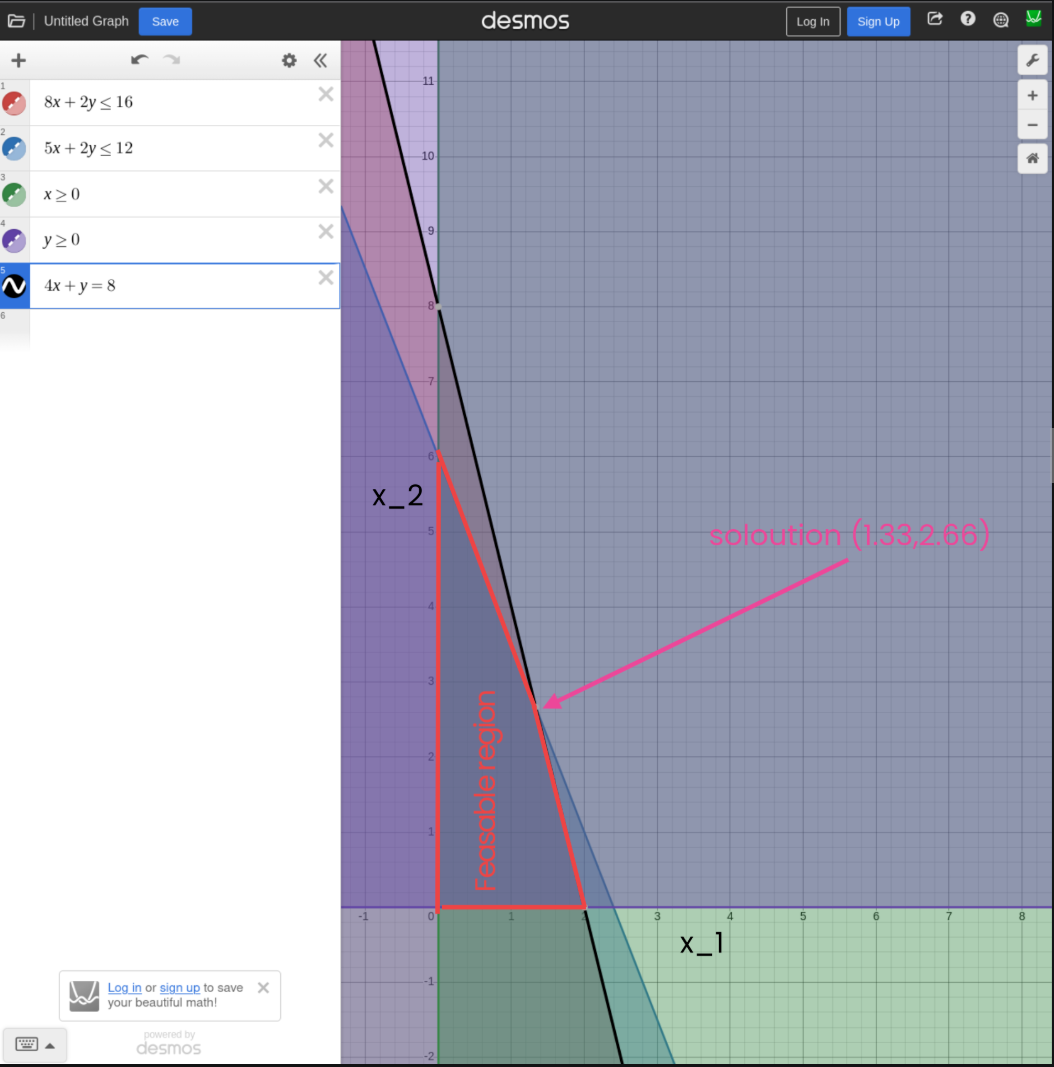

**Case B**
This LP is infeasable becasue its contraints don't produce a convex set.  This is becase you cannot select a point in $2x_1+2x_2\leq8$ and $x_1-x_2\geq5$ that also satifys $x_1\geq0$.Graph Below 

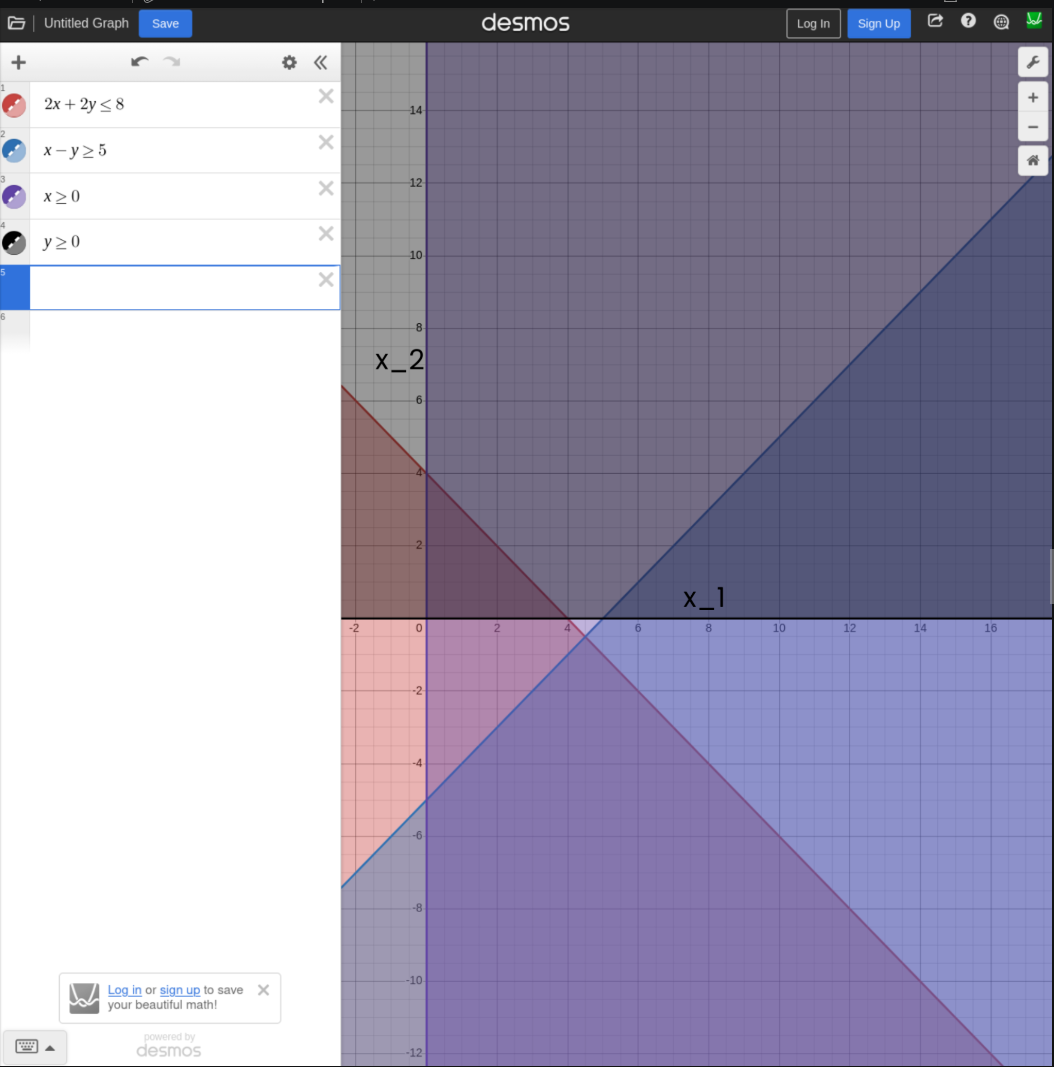

**Case C**
This LP is unbounded because as you move along the $x_1-x_2 \leq 4$ constraint you never reach a nother constraint in the maximum direction. Graph Below

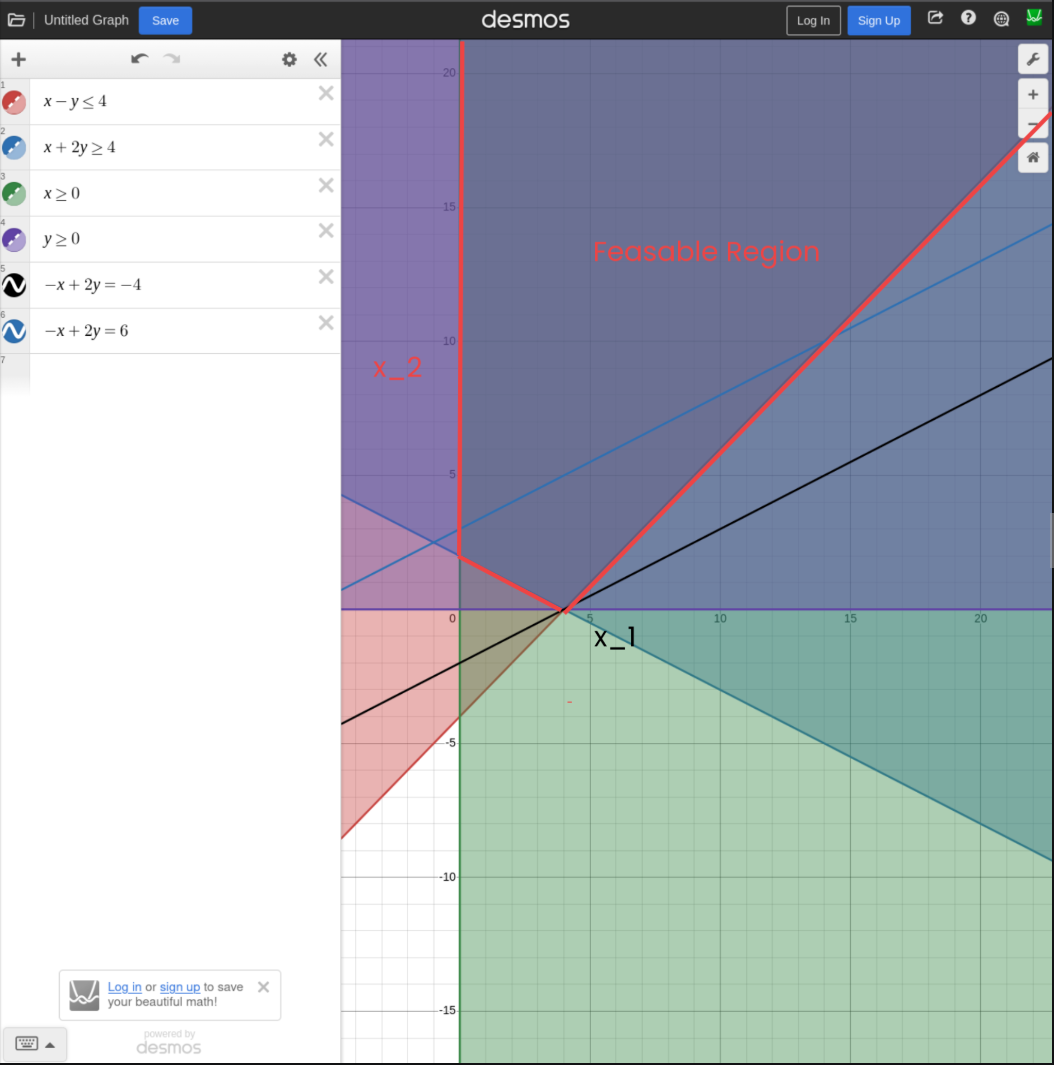

**Case D**
This LP has a unique soloution which occurs at $x_1=4$ and $x_2=0$ resulting in a objective function equal to -4. Graph Below

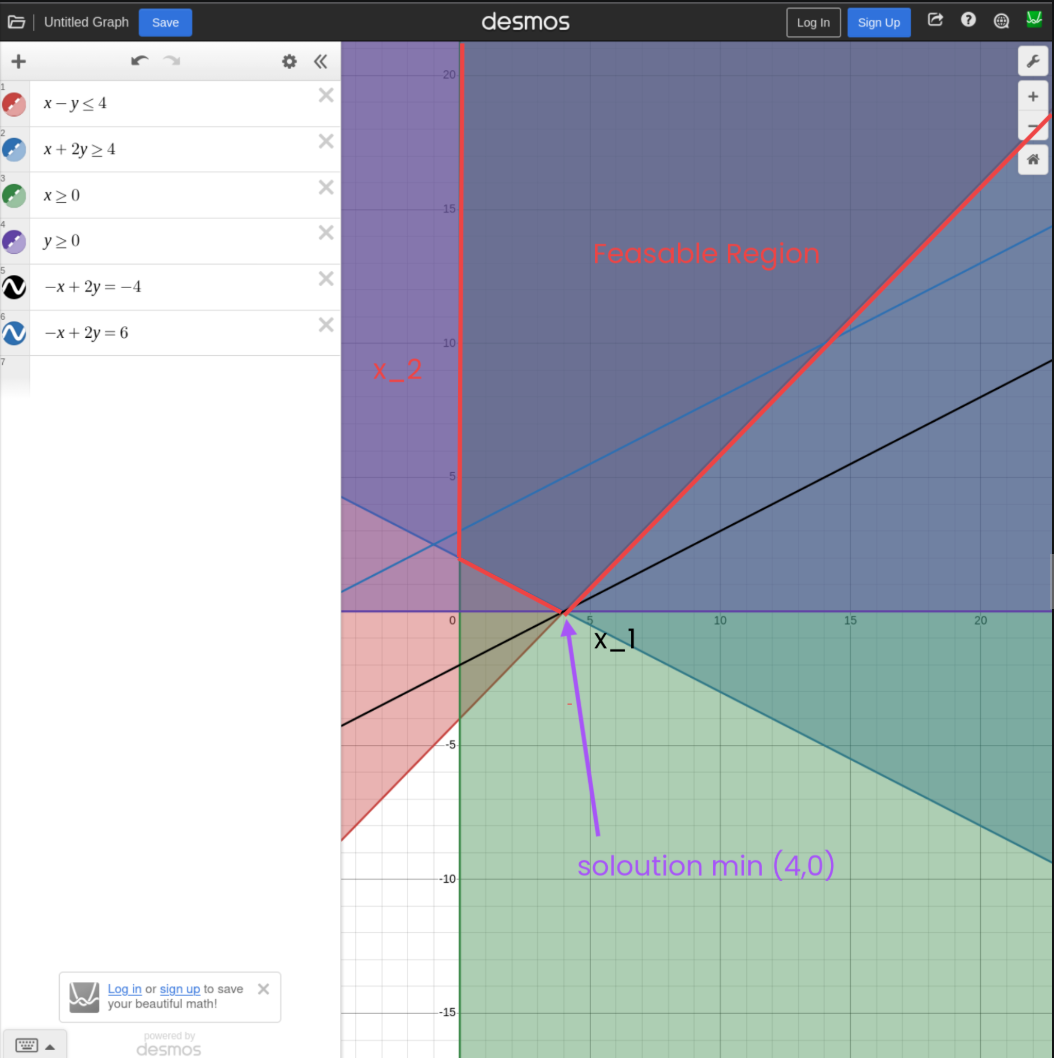

When comparing cases C to D you can find that the feasable region is only bounded in one direction. This shows that you dont need a bounded feasable region to have a bounded optimization problem you just need to make sure you are optimizing towards a area of the region that is bounded. 

## 3: JMAP

### Mmmmmmmmmmmmmmmm. Pork.

Jacob's Meat Packing Plant produces 480 hams, 400 pork bellies, and 230 picnic hams every day. Each of these products can be sold either fresh or smoked. The total number of hams, bellies, and picnics that can be smoked during a normal working day is 420. In addition, up to 250 products can be smoked on overtime, at a higher cost (and therefore a lower net profit). The net profits (in dollars per product) are the following:

| Product | Fresh | Smoked (Regular) | Smoked (Overtime) |
| :-- | --: | --: | --: |
| Hams | 8 | 14 | 11 |
| Bellies | 4 | 12 | 7 |
| Picnics | 4 | 13 | 9 |

Products may be left unused. Treat quantities as continuous in this LP.

### 3(a): Formulate the pork instance

Write a linear program that will maximize the total net profit. Define your decision variables and write out the objective and constraints for this instance.

**Formulation for 3(a):**

Type your answer in Markdown, or insert a clear photograph/scan of handwritten work. Include the requested variables, model, or results.

$$
\begin{aligned}
\max\quad &8H_f+14H_{sr}+11H_{so}+4B_f+12B_{sr}+7B_{so}+4P_f+12P_{sr}+9P_{so}\\
\text{subject to}\quad &H_f+H_{so}+H_{sr}\leq480,\\
&B_f+B_{so}+B_{sr}\leq400\\
&P_f+P_{so}+P_{sr}\leq230\\
&H_{sr}+B_{sr}+P_{sr} \leq420\\
&H_{so}+B_{so}+P_{so} \leq250\\
& H_f, H_{sr}, H_{so},B_f, B_{sr}, B_{so},P_f, P_{sr}, P_{so} \geq 0
\end{aligned}
$$

### 3(b): Implement and solve the pork instance

Create your instance from part 3(a) in the JuMP modeling language and solve it with HiGHS, printing the solver status, total profit, and number of each type of meat product to prepare by each method.

In [16]:
# Implement and solve your model here.
# Print the status, total profit, and production quantities.

using JuMP, HiGHS
pork=Model(HiGHS.Optimizer)
@variable(pork, Hf>=0)
@variable(pork, Hso>=0)
@variable(pork, Hsr>=0)
@variable(pork, Bf>=0)
@variable(pork, Bso>=0)
@variable(pork, Bsr>=0)
@variable(pork, Pf>=0)
@variable(pork, Psr>=0)
@variable(pork, Pso>=0)
@constraint(pork,Hf+Hso+Hsr<=480)
@constraint(pork,Bf+Bso+Bsr<=400)
@constraint(pork,Pf+Pso+Psr<=230)
@constraint(pork,Hsr+Bsr+Psr<=420)
@constraint(pork,Hso+Bso+Pso<=250)
@objective(pork,Max,8Hf+14Hsr+11Hso+4Bf+12Bsr+7Bso+4Pf+12Psr+9Pso)


optimize!(pork)
status = termination_status(pork)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(pork) || error("No feasible optimal solution is available.")

#Print Status, Optimal Decisions, Objective Value
println("Termination status: ", status)
println("Maximum Profit: ",objective_value(pork), " dollars")
println("Fresh Ham: ", value(Hf), " Units")
println("Fresh Bellie: ", value(Bf), " Units")
println("Fresh Picnic: ", value(Pf), " Units")
println("Smoked Regular Ham: ", value(Hsr), " Units")
println("Smoked Regular Bellie: ", value(Bsr), " Units")
println("Smoked Regular Picnic: ", value(Psr), " Units")
println("Smoked Overtime Ham: ", value(Hso), " Units")
println("Smoked Overtime Bellie: ", value(Bso), " Units")
println("Smoked Overtime Picnic: ", value(Pso), " Units")

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 5 rows; 9 cols; 15 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [4e+00, 1e+01]
  Bound   [0e+00, 0e+00]
  RHS     [2e+02, 5e+02]
Presolving model
5 rows, 9 cols, 15 nonzeros 0s
5 rows, 9 cols, 15 nonzeros 0s
Presolve reductions: rows 5(-0); columns 9(-0); nonzeros 15(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -8.0999931148e+01 Ph1: 5(15); Du: 9(80.9999) 0.0s
         10     1.0890000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 10
Objective value     :  1.0890000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Termination status: OPTIMAL
Maximum Profit: 10890.0 dollars
Fresh Ham:

**Results for 3(b):**

Type your answer in Markdown, or insert a clear photograph/scan of handwritten work. Include the requested variables, model, or results.

The maximum Profit that can be acheived in this problem is 10,890 dollars. To acheive this you must produce 440 units fresh ham, 400 units regular smoked bellie, 20 units regular smoked picnic, 40 units smoked overtime ham, 210 units ovetime smoked picnic and 0 units Smoked overtime bellie, smoked regular ham, fresh bellie and fresh picnic.

### 3(c): Mission Impossible — the general model

> Lisa: “I'm going to become a vegetarian”  
> Homer: “Does that mean you're not going to eat any pork?”  
> Lisa: “Yes”  
> Homer: “Bacon?”  
> Lisa: “Yes Dad”  
> Homer: “Ham?”  
> Lisa: “Dad all those meats come from the same animal!”  
> Homer: “Right Lisa, some wonderful, magical animal!”

Jacob's Meat Alternative Plant (JMAP) produces a set of plant-based pork products $P$ using Impossible Meat. For example, it may be that $P=\{\text{Ham, Bacon, Pork Belly}\}$. A product $p\in P$ can be prepared (and then sold) using a cooking method $c\in C$. For example, it may be that $C=\{\text{Fresh, Smoked, Fried}\}$.

JMAP produces $b_p$ products of type $p\in P$ per day. The total number of products that can be prepared using cooking method $c\in C$ each day is given by the parameter $u_c$. The revenue to JMAP from product $p\in P$ when prepared by cooking method $c\in C$ is $h_{pc}$, before cooking cost. Each cooking method $c\in C$ has an associated cost of $q_c$ for any product sold using that method. Products may be left unused, and quantities are continuous.

Write a linear program that will maximize the total net profit for JMAP. Just write the mathematical model using general notation, defining your decision variables.

**Formulation for 3(c):**

Type your answer in Markdown, or insert a clear photograph/scan of handwritten work. Include the requested variables, model, or results.

Sets: P (products), C (Method of Sale)

Parameters: $b_p$ (units available per product), $u_c$ (units availble per process), $h_{pc}$ (sale gross profit), $q_c$ (sale costs per process)


Objective function sums net profit of every product across each process and maximizes it.
$$
\begin{aligned}
\max\quad \sum_{p \epsilon P}\sum_{c \epsilon C} (h_{pc}-q_c)x_{pc}\\
\end{aligned}
$$  

The first set of constraints sums the number of products per process and makes sure it is less than or equal to the limit of units that can be processed by that process.

$$
\begin{aligned}
\sum_{p \epsilon P}x_{pc}\leq u_c \quad \forall p \epsilon P\\
\end{aligned}
$$  

The second set of constraints sums the number of products processed and makes sure it is less than or equal to the limit of units are avalible to sell that day.

$$
\begin{aligned}
\sum_{c \epsilon C}x_{pc}\leq b_p \quad \forall c \epsilon C\\
\end{aligned}
$$  

The final constraint makes sure a non-negitive amount of products is processed

$$
\begin{aligned}
\ x_{pc} \geq 0 \quad \forall c \epsilon C, p\epsilon P\\
\end{aligned}
$$  

### 3(d): Implement and solve the general model

Implement your model from part 3(c) in JuMP on the supplied data. Solve it with HiGHS and print the solver status, maximum total net profit, and the amount of each product to prepare by each method. You may enter the data yourself or use the supplied CSV-loading code below.

The data are the five-product, five-method instance from `pork-general.csv`, arranged into three tables. In this instance, subtract the listed cooking costs from the revenues; the table in part 3(a) already gave net profits.

#### Supplied data for 3(d)

The full instance has five products and five methods. The `data/` folder contains three CSV files. Their labels connect the tables; their row order has no mathematical significance.

| File | Columns | Meaning and units |
| :-- | :-- | :-- |
| `products.csv` | `product, availability` | Product label and $b_p$ (units/day) |
| `methods.csv` | `method, capacity, cost` | Method label, $u_c$ (units/day), $q_c$ (dollars/unit) |
| `revenues.csv` | `product, method, revenue` | One row per pair; $h_{pc}$ (dollars/unit) |

The supplied code creates `P` and `C`, dictionaries `b`, `u`, `q`, and a dictionary `h` indexed by pairs. For example, `b["Ham"]` is the daily Ham availability, and `h[("Ham", "Fresh")]` is its revenue per unit when prepared Fresh. You do not need to write or modify the data-loading code.

The supplied loader works from the repository root or the folder containing this notebook. If you get a missing-file error, check that the complete copied `data/` folder is beside your working notebook.


In [17]:
# Locate this assignment, including when a notebook kernel starts at the repo root.
notebook_dirs = [
    @__DIR__,
    joinpath(pwd(), "student-work", "hw02"),
    joinpath(pwd(), "assignments", "hw02"),
]
notebook_index = findfirst(
    directory -> isfile(joinpath(directory, "hw02.ipynb")), notebook_dirs,
)
isnothing(notebook_index) && error(
    "Open the course repository or run from the folder containing hw02.ipynb."
)
data_dir = joinpath(notebook_dirs[notebook_index], "data")
for filename in ("products.csv", "methods.csv", "revenues.csv")
    isfile(joinpath(data_dir, filename)) || error(
        "Missing $(filename) in $(data_dir). Keep the complete data folder beside your HW02 notebook."
    )
end
products = CSV.read(joinpath(data_dir, "products.csv"),
    DataFrame; stringtype=String)
methods = CSV.read(joinpath(data_dir, "methods.csv"),
    DataFrame; stringtype=String)
revenues = CSV.read(joinpath(data_dir, "revenues.csv"),
    DataFrame; stringtype=String)

P = products.product
C = methods.method
b = Dict(row.product => row.availability
    for row in eachrow(products))
u = Dict(row.method => row.capacity for row in eachrow(methods))
q = Dict(row.method => row.cost for row in eachrow(methods))
h = Dict((row.product, row.method) => row.revenue
    for row in eachrow(revenues))

# Check labels and completeness before using the data.
@assert length(unique(P)) == length(P)
@assert length(unique(C)) == length(C)
@assert nrow(revenues) == length(h) == length(P) * length(C)
@assert all(haskey(h, (p, c)) for p in P, c in C)

println("Products: ", join(P, ", "))
println("Methods: ", join(C, ", "))
println("Revenue entries: ", length(h))


Products: Ham, PorkBelly, Picnic, Bacon, Tenderloin
Methods: Fresh, SmokedRegular, SmokedOvertime, Cured, Pickled
Revenue entries: 25


In [18]:
# Implement and solve your model here.
# Print the status, total profit, and production quantities.

# Build and solve the indexed JMAP model here.
# Report allocations, supply/capacity use, and net profit.

using JuMP, HiGHS

jmap=Model(HiGHS.Optimizer)

@variable(jmap,x[P,C] >=0)

@constraint(jmap,process_limit[c in C],
    sum(x[p,c] for p in P) <= u[c])

@constraint(jmap,product_limit[p in P],
    sum(x[p,c] for c in C) <= b[p])

@objective(jmap, Max, sum((h[p, c] - q[c]) * x[p, c] for p in P, c in C))

optimize!(jmap)
status = termination_status(jmap)
status == MOI.OPTIMAL || error("HiGHS stopped with status $(status).")
is_solved_and_feasible(jmap) || error("No feasible optimal solution is available.")
solutions= Dict((p,c) => value(x[p,c]) for p in P, c in C)
solution= Dict((p,c) => value(x[p,c]) for p in P, c in C if value(x[p,c]) > 1e-6)

#Print Status, Objective Value, 
println("Termination status: ", status)
println("Maximum Daily Profit: ",objective_value(jmap), " dollars")

#Print Product and amount Produced\
println("")
for p in P, c in C
    if haskey(solution,(p,c))
        println("Product: ",p," Process: ", c," Units Produced: ",solution[(p,c)])
    end
end

#Print Product Usage
println("")
for p in P
    product_use=sum(i for ((product,c),i) in solution if product == p; init=0.0)
    println("Product: ", p, " Total units used: ", product_use)
    product_left=b[p]-product_use
    println("Product: ", p, " Total units left: ", product_left)
end

#Print Capacity Usage
println("")
for c in C
    capacity_use=sum(i for ((p,capacity),i) in solution if capacity == c; init=0.0)
    println("Process: ", c, " Total Capacity used: ", capacity_use)
    capacity_left=u[c]-capacity_use
    println("Process: ", c, " Total capacity left ", capacity_left)
end

#Print Profit
println("")
profit=sum(i*(h[p, c] - q[c]) for ((p,c),i) in solution; init=0.0)
println("Profit calculated from outputs: ", profit, " dollars")


Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: blastrampoline 
LP has 10 rows; 25 cols; 50 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+00, 1e+01]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 5e+03]
Presolving model
10 rows, 24 cols, 48 nonzeros 0s
7 rows, 15 cols, 25 nonzeros 0s
Presolve reductions: rows 7(-3); columns 15(-10); nonzeros 25(-25) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0299901578e+02 Ph1: 7(24); Du: 14(102.999) 0.0s
         10    -1.4725000000e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 10
Objective value     :  1.4725000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Termination status

**Results for 3(d):**

Type your answer in Markdown, or insert a clear photograph/scan of handwritten work. Include the requested variables, model, or results.

The maximum profit from this LP is 14,725 dollars. This is acheived by producing 380 units Fresh Ham, 100 Units Cured Ham, 230 units Regular Smoked Pork Belly, 170 Units Pickled Pork Belly, 230 units Pickled Picnic, 310 units Fresh Bacon, 190 units Regular smoked bacon, and 245 units Overtime Smoked Tenderloin.  

This results in all Products being processed with 4310 units of fresh capacity left, 0 regular smoke units of capacity left, 5 units of overtime smoking left, 0 units of cureing and pickleing capacity left.  

Spare capacity in one method need not eliminate the value of capacity in another in this problem becasue different methods have different cost and different meats have different profits. Thus you have to consider net profit rather than gross profit which means that different products may profit better in differnt methods even though gross profit on one method may be greatest,


## Collaboration and LLM-use statement — required

Complete this statement as the **very last part of your homework**. Be specific enough that a reader can understand what work you did yourself and how others or LLMs helped you learn.

- **People:** Give the name of every person you collaborated with, identify the problem/subpart you discussed, and explain the nature of the collaboration. If you worked alone, explicitly state that you did not collaborate with anyone.
- **LLMs/tools:** Name every LLM or AI assistant you used and identify the model/version as precisely as available. If the interface did not show a model/version, say so. If you used none, explicitly state that you did not use an LLM or AI assistant.
- **Specific assistance and learning:** For each tool, identify the problem/subpart, describe what you asked it to help with, what suggestions you used or rejected, and how the interaction helped you understand the mathematics or implementation. Explain how you checked the suggestions. “I used ChatGPT for help” is not sufficiently specific.

Disclosure does not replace the requirement that your submitted formulation, implementation, and explanation be your own work and that you understand them.


**People and collaboration:**

I worked alone on this homework

**LLMs/tools and models:**

Google Gemini 3.5 Flash Lite

**How I used the assistance, what I learned, and how I checked it:**

I used this on problem 3 to asssist in extracting values from a dictionary with touples for the key. It provided the following format which 
product_use=sum(i for ((product,c),i) in soloution if product == p; init=0.0) which I then had it explain and it provided : 

sum(...): The built-in Julia function that adds up a collection of numbers.

for ((product, c), i) in soloution:

    This iterates through your dictionary (assuming it's named solution).

    It uses tuple destructuring, meaning it automatically unpacks each dictionary entry. The key—which is a tuple (product, c)—is split into separate variables product and c, and the dictionary's value is stored in i.

if product == p:

    A conditional filter. It tells the generator to only include values in the sum where the product matches your current target product p.

; init=0.0:

    Sets the starting value of the sum to 0.0. This is a safety feature: if no matching entries are found in the dictionary, sum() would normally throw an error on an empty collection, but init=0.0 ensures it gracefully returns 0.0 instead.


I then used this infomation and fomating throughut the rest of the problem and extended some of what I learned to the following problem.  I checked its results by asking for links to the documentation wich it provided as https://docs.julialang.org/en/v1/base/collections/?utm_source=gemini#Base.sum. and https://docs.julialang.org/en/v1/manual/arrays/#man-comprehensions 
